# ECE1786 Final Project -- Prod Match

Date: 2024/11/30

There are two processing of this projdct:
1. The first processing is use the multi-model (InternVL) extract the feature from the product information (image, description). In this project, we just focused on the features $ Color, Width, Length, Height, Price$. The goal of this processing is label the product base the feature mentioned above.

2. The Second processing is use the multi-model (InternVL) extract the feature from the user query.

The goal of this project is understanding the user query then do the product recommondation.

## ✊ Environment Setup

Run this first to install the dependence. ❄

In [1]:
!pip install transformers==4.37.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 3.2.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.


In [2]:
!pip install decord -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 81.2 MB/s eta 0:00:00


In [3]:
!pip install gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.2/320.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.2/168.2 kB 14.6 MB/s eta 0:00:00


## ✋ Library Import

In [4]:
import numpy as np
import torch
import torchvision.transforms as T
from decord import VideoReader, cpu
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import re
import json

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

In [5]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

shared_folder_path = '/content/drive/MyDrive/ECE1786/ECE1786_project'


Mounted at /content/drive


## 📖 Basic Dataset Loading

In this part, the product dataset will be prepared for the future do the recommendation. The product data stores as CSV file contains information below:

- img_dir: image folder path which will contain product's image and an txt description.  
- price, color, length, width, height


In [6]:
# product database
product_csv_path = "/content/drive/MyDrive/ECE1786/ECE1786_project/product_database.csv"
product_dataset = pd.read_csv(product_csv_path)

product_dataset.drop(columns=['Unnamed: 0'], inplace=True)
product_dataset.head()

# product_database.to_csv('/content/drive/MyDrive/ECE1786/ECE1786_project/product_database.csv')


,img_dir,price,color,length,width,height,link
0,1,129.99,white,39.4,18.9,30.5,https://www.amazon.ca/Rolanstar-Computer-Outle...
1,2,169.99,white,55.1,18.9,30.5,https://www.amazon.ca/Rolanstar-Computer-Outle...
2,3,149.99,white,47.2,18.9,30.5,https://www.amazon.ca/Rolanstar-Computer-Outle...
3,4,199.99,white,63.0,18.5,30.7,https://www.amazon.ca/Rolanstar-Computer-Drawe...
4,5,299.87,maple,55.0,28.0,28.0,https://www.amazon.ca/SHW-55-Inch-Electric-Adj...


## 🤖 Loading Model

**Model**: InternVL-8b (fine-tuninged)

How to run: Makesure the **path** is your fine-tuning model path.

After run you will have InternVL-8b model be setup, which is an multi-model, accept image and text as input.


In [7]:
def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

In [29]:
# path = '/content/drive/MyDrive/ECE1786/ECE1786_project/InternVL-main/internvl_chat/work_dirs/internvl_chat_v2_0/internvl_8b_lora_merged_new' # fine-tuned
path = '/content/drive/MyDrive/ECE1786/ECE1786_project/internvl-8B' # baseline
model = AutoModel.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_flash_attn=True,
    trust_remote_code=True).eval().cuda()
tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, use_fast=False)
generation_config = dict(max_new_tokens=128, do_sample=True)
print("Model Loading in Success!")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Model Loading in Success!


## 🏪 Processing I (Product Collect):

**User story**: As an store manage, I want to upload new product to product dataset for customer choice and product can be auto labeled by the model. Also the new product will be stored to the product dataset.

```
Example:
Input:
  - image_dir: "/content/drive/MyDrive/ECE1786/ECE1786_project/test/1"  # Folder contain product images
  - Product Describtion:  "SHW Desk Home Office 40-Inch Computer Table, Black"  # Product discribtion
  - price: 88.97 # price of product
  - product_url: "https://example.com/product" # link of product
Output:
  - img_dir    /content/drive/MyDrive/ECE1786/ECE1786_project...
  - price                       88.97
  - color                       black
  - length                      40.0
  - width                      19.0
  - height                      28.0
```



In [9]:
class Product():
  def __init__(self, img_dir, description, price, url):
    self.img_dir = img_dir
    self.description = description
    self.price = price
    self.url = url

    self.color = None
    self.length = None
    self.width = None
    self.height = None

  def upload_product(self, feature, data):
    if feature == 'color':
      self.color = data
    elif feature == 'length':
      self.length = data
    elif feature == 'width':
      self.width = data
    elif feature == 'height':
      self.height = data

  def check_product(self):
    if os.path.exists(self.img_dir):
      return True
    else:
      return False

    if self.color and self.length and self.width and self.height and self.price and self.url:
      return True
    else:
      return False

  def unit_convert(self, unit, value):
    # convet unit to inch
    result = value
    if unit == "cm":
      result = value * 0.393701
    elif unit == "m":
      result = value * 39.3701
    elif unit == "mm":
      result = value * 0.0393701
    elif unit == "ft":
      result = value * 12
    elif unit == "in":
      result = value
    else:
      result = value

    return result

  def __str__(self):
    message = (
        f"--Product Information--\n"
        f'image_dir: {self.img_dir}\n'
        f'description: {self.description}\n'
        f'price: {self.price}\n'
        f'url: {self.url}\n'
        f'color: {self.color}\n'
        f'length: {self.length}\n'
        f'width: {self.width}\n'
        f'height: {self.height}\n'
    )
    return message


In [10]:
# Define the input method
image_dir = "/content/drive/MyDrive/ECE1786/ECE1786_project/test/1"  # @param {type: "string"}
description = "SHW Desk Home Office 40-Inch Computer Table, Black"  # @param {type: "string"}
price = 88.97 # @param {"type":"number"}
product_url = "https://example.com/product" # @param {type: "string"}

# check images number


def product_feature_extract(model, image_dir, description, price):
  num_images = 0
  image_paths = []
  for img_name in os.listdir(image_dir):
    if img_name.endswith(".jpg"):
      img_path = os.path.join(image_dir, img_name)
      num_images +=1
      image_paths.append(img_path)
  print(f"Number of images: {num_images} \nList: {image_paths}")

  if num_images > 10:
    print("Too much images found in the folder (max = 12)!")
    return None

  if num_images == 0:
    print("No image found!")
    return None
  elif num_images == 1:
    img_path = image_paths[0]
    prompt_sg = (
      f'Product Image: <image>\n'
      f'Product Title: {description}\n'
      f'Product Price: {price}\n'
      f'Task: Analyze the provided product image and title to accurately extract key features such as color, dimensions (length, width, height), unit of measurement, and price. Ensure the output is formatted as a single-line JSON string.\n'
      f'Output format: {{"color": "[COLOR]", "length": [LENGTH], "width": [WIDTH], "height": [HEIGHT], "unit": "[UNIT]", "price": [PRICE]}}.\n'
      f'Features: '
    )
    pixel_values = load_image(img_path, max_num=12).to(torch.bfloat16).cuda()
    question = prompt_sg
    response = model.chat(tokenizer, pixel_values, question, generation_config)
    # print(f'User: {question}"{response} \n"')

  elif num_images > 1:
    prompt_mt = (
      f'Product Image 1: <image>\n'
      f'Product Image 2: <image>\n'
      f'Product Title: {description}\n'
      f'Product Price: {price}\n'
      f'Task: Analyze the provided product images and title to accurately extract key features such as color, dimensions (length, width, height), unit of measurement, and price. Use the information from both images to ensure accuracy. Ensure the output is formatted as a single-line JSON string.\n'
      f'Output format: {{"color": "[COLOR]", "length": [LENGTH], "width": [WIDTH], "height": [HEIGHT], "unit": "[UNIT]", "price": [PRICE]}}.\n'
      f'Features: '
    )

    # multi-image multi-round conversation, combined images
    pixel_values_list = []
    for image_path in image_paths:
        # Load and preprocess each image
        pixel_values = load_image(image_path, max_num=12).to(torch.bfloat16).cuda()
        pixel_values_list.append(pixel_values)

    # Concatenate all images along the batch dimension
    pixel_values = torch.cat(pixel_values_list, dim=0)
    response, history = model.chat(tokenizer, pixel_values, question, generation_config,
                                  history=None, return_history=True)
    # print(f'User: {question}\nAssistant: {response} \n')

  return response

def product_create(response, image_dir, description, price, product_url):
  if response.startswith("```json") and response.endswith("```"):
        response = response.strip("```json").strip()

  model_result = json.loads(response)
  product = Product(image_dir, description, price, product_url)
  for feature in model_result:
    if feature == 'length' and 'unit' in model_result:
      model_result[feature] = product.unit_convert(model_result['unit'], model_result[feature])
    elif feature == 'width' and 'unit' in model_result:
      model_result[feature] = product.unit_convert(model_result['unit'], model_result[feature])
    elif feature == 'height' and 'unit' in model_result:
      model_result[feature] = product.unit_convert(model_result['unit'], model_result[feature])

    product.upload_product(feature, model_result[feature])

  print(model_result)

  return product

def upload_product(df, product):
  # img_dir	price	color	length width	height
  if product.check_product():
    df.loc[len(product_dataset)] = [product.img_dir, product.price, product.color, product.length, product.width, product.height, product.url]
    return True
  else:
    return False

feature_response = product_feature_extract(model, image_dir, price, description)
new_product = product_create(feature_response, image_dir, description, price, product_url)
# upload_product(product_dataset, new_product)

print(product_dataset.iloc[-1])

Number of images: 1 
List: ['/content/drive/MyDrive/ECE1786/ECE1786_project/test/1/1.jpg']
{'color': 'black', 'length': 40.0, 'width': 19.0, 'height': 28.0, 'unit': 'inch', 'price': 88.97}
img_dir                                                  200
price                                                 280.01
color                                                   wood
length                                                  63.0
width                                                   35.4
height                                                  29.3
link       https://www.temu.com/ca/---live---table--wood-...
Name: 199, dtype: object


## 🦸Processing II (User Query Feature Extract)

user story: As a user, I want to input and query to search the product, the model have ability to analysis my user query and extract the information from my query.

```
Example:
Input: "Do you have a wooden work desk in dark color, with dimensions around 120 cm long, 60 cm wide, and a height of 75 cm, for less than $150?"
Output: {"color": "Dark", "length": "120 cm", "width": "60 cm", "height": "75 cm", "price": 150}
```



In [11]:
def user_query_test(model, user_query):
  prompt_user = (
    f'Task: Extract key product features from the user\'s query. The features may include any of the following keys: \'color\', \'length\', \'width\', \'height\', \'price\', Does no other keys\n'
    f'Query: {user_query}\n'
    f'Expected Output: Provide a JSON object containing only the relevant keys and their corresponding values based on the query.\n'
    f'Example Query: Can you find me a black study desk, about 48 inches tall? My budget is under $200.\n'
    f'Example Output: {{"color": "Black", "height": "48 inch", "price": 200}}\n'
    f'Features: '
  )
  response, history = model.chat(tokenizer, None, prompt_user, generation_config, history=None, return_history=True)
  # print(f'User: {prompt_user}"{response}"')
  try:
    parsed_response = json.loads(response)
    return parsed_response
  except json.JSONDecodeError as e:
    # Handle invalid JSON response
    print(f"Error decoding JSON: {e}")
    print(f"Raw response: {response}")
    return None



user_query = "Do you have a wooden work desk in dark color, with dimensions around 120 cm long, 60 cm wide, and a height of 75 cm, for less than $150?" # @param {type: "string"}

response = user_query_test(model, user_query)

## 🧲 Product Matching Part

In [12]:
# MATCHING MODEL LOADING
matching_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
def convert_sizes_to_inch(json_input):
    # Conversion factors to inches
    conversion_factors = {
        "ft": 12,       # 1 foot = 12 inches
        "cm": 0.393701, # 1 cm = 0.393701 inches
        "m": 39.3701,   # 1 meter = 39.3701 inches
        "inch": 1       # 1 inch = 1 inch
    }

    def convert_size(size_value):
        for unit, factor in conversion_factors.items():
            if size_value.endswith(unit):
                # Extract the numeric value and convert it to inches
                numeric_value = float(size_value.replace(unit, "").strip())
                return round(numeric_value * factor, 2)  # Round to 2 decimal places
        return float(size_value)  # Return None if no valid un   it is found

    data = json_input

    # Iterate through keys and convert size-related values to inches
    for key in ["length", "width", "height"]:
        if key in data and isinstance(data[key], str):  # Check if the key exists and is a string
            value = data[key]
            #keep number
            value = re.sub(r'\D', '', value)

            converted_value = convert_size(value)
            if converted_value is not None:
                data[key] = converted_value

    # Return the modified JSON as a string
    return data

In [14]:
def color_embedding_function(model, color_name):
  return model.encode(color_name)

def find_top_matches(model, df, inputs, color_embedding_function, n=1, weights=None):
    """
    Finds the top N closest matches in a database based on the specified labels using a weighted scoring system.

    Args:
        csv_file (str): Path to the CSV file containing the database.
        inputs (dict): Dictionary containing labels (e.g., color, length, height, depth, and price).
        color_embedding_function (callable): Function to convert color labels into embeddings.
        n (int): Number of top matches to return.
        weights (dict): Weights for each component in the matching process (default: equal weights).
                        Example: {'color': 0.4, 'dimensions': 0.4, 'price': 0.2}

    Returns:
        pd.DataFrame: DataFrame containing the top N matches with their table_id and scores.
    """
    # Define default weights if none are provided
    if weights is None:
        weights = {'color': 0.4, 'dimensions': 0.4, 'price': 0.2}

    # Initialize scores
    df['color_score'] = 0
    df['dimension_score'] = 0
    df['price_score'] = 0
    df['final_score'] = 0

    # Color Matching
    if 'color' in inputs:
        input_color_embedding = color_embedding_function(model, inputs['color'].lower())
        df['color_score'] = df['color'].apply(
            lambda db_color: cosine_similarity(
                [input_color_embedding],
                [color_embedding_function(model, db_color)]
            )[0][0]
        )

    # Dimension Matching (handles missing dimensions)
    dimension_keys = ['length', 'height', 'width']
    input_dimensions = {key: inputs[key] for key in dimension_keys if key in inputs}

    if input_dimensions:
        for key in input_dimensions:
            df[f'{key}_diff'] = df[key].apply(lambda x: abs(x - input_dimensions[key]))
        max_diffs = df[[f'{key}_diff' for key in input_dimensions]].max(axis=0)
        df['dimension_score'] = 1 - df[[f'{key}_diff' for key in input_dimensions]].sum(axis=1) / max_diffs.sum()

    # Price Matching
    if 'price' in inputs:
        # price_value = inputs['price']
        # match = re.search(r'\d+(\.\d+)?', price_value)
        # price_value = match.group() if match else None

        max_price_diff = df['price'].max() - df['price'].min()
        df['price_score'] = df['price'].apply(
            lambda x: 1 - abs(x -  inputs['price']) / max_price_diff
        )

    # Calculate Weighted Final Score
    df['final_score'] = (
        weights['color'] * df['color_score'] +
        weights['dimensions'] * df['dimension_score'] +
        weights['price'] * df['price_score']
    )

    # Sort by final score in descending order and get the top N matches
    top_matches = df.nlargest(n, 'final_score')[['img_dir', 'price', 'link', 'final_score']]

    return top_matches if not top_matches.empty else None

In [15]:
user_query = "A maple table with a length of 48 inches, width of 24 inches, and height of 28 inches, priced at $249.87." # @param {type: "string"}

def product_matching(model, matching_model, user_query):
  user_query_respose = user_query_test(model, user_query)

  if user_query_respose is None:
    print("User query extract failed!")
    return None

  weights = {'color': 0.5, 'dimensions': 0.3, 'price': 0.2}

  inputs = convert_sizes_to_inch(user_query_respose)
  print(inputs)
  best_match = find_top_matches(matching_model, product_dataset, inputs, color_embedding_function, n=5, weights=weights)

  # print("Best Match:\n", best_match)
  return best_match

result = product_matching(model,matching_model, user_query)
print(result)

{'color': 'Maple', 'length': 48.0, 'width': 24.0, 'height': 28.0, 'price': 249.87}
    img_dir   price                                               link  \
5         6  249.87  https://www.amazon.ca/SHW-55-Inch-Electric-Adj...   
41       42  359.99  https://www.amazon.ca/dp/B0BVV6H6CG/ref=sspa_d...   
6         7  199.87  https://www.amazon.ca/SHW-55-Inch-Electric-Adj...   
40       41  329.99  https://www.amazon.ca/dp/B08L5YQVXR/ref=sspa_d...   
4         5  299.87  https://www.amazon.ca/SHW-55-Inch-Electric-Adj...   

    final_score  
5      1.000000  
41     0.993581  
6      0.985263  
40     0.983507  
4      0.980829  


### Visualize Results

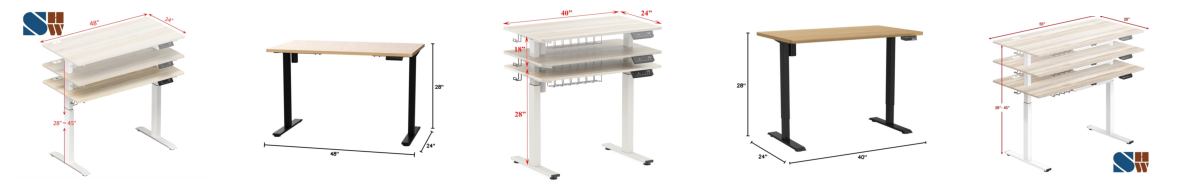

    img_dir   price                                               link  \
5         6  249.87  https://www.amazon.ca/SHW-55-Inch-Electric-Adj...   
41       42  359.99  https://www.amazon.ca/dp/B0BVV6H6CG/ref=sspa_d...   
6         7  199.87  https://www.amazon.ca/SHW-55-Inch-Electric-Adj...   
40       41  329.99  https://www.amazon.ca/dp/B08L5YQVXR/ref=sspa_d...   
4         5  299.87  https://www.amazon.ca/SHW-55-Inch-Electric-Adj...   

    final_score  
5      1.000000  
41     0.993581  
6      0.985263  
40     0.983507  
4      0.980829  


In [ ]:
# plt image
import matplotlib.pyplot as plt
from PIL import Image

def display_images(results):
    num_images = len(results)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image_path = str(results.iloc[i]['img_dir'])
        image_path = os.path.join("/content/drive/MyDrive/ECE1786/ECE1786_project/data", image_path)
        #get jpg
        for file in os.listdir(image_path):
            if file.endswith(".jpg"):
                image_path = os.path.join(image_path, file)
                break
        image = Image.open(image_path)
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.axis('off')
    plt.show()

display_images(result)
print(result)

# 🎯 Accuracy Testing

For this part using to test the accuracy. There are 3 accuracy testing:
1. Maching Pipeline Accuracy: This part using to test the product matching accuracy.
2. Feature Extract Accuracy: This part using to test the product feature Extract accuracy.
3. User Query Extract Accuracy: This part using to test the user query extract accuracy.

## 💁 Matching pipeline Accuracy

**Test Query Design**: We create test query basic one specific product. If the system success matching, that product will in the return list. Cause it with the high score of matching.

Matching Test File create by GPT. Provide one product information including deimension, price and color, then design the query for that product and label with the product id. Example below:

```
Product Information:
  {"color": brown, 'length': 50.0, 'width': 20.0, 'height':29.4, 'price': 164.99}

Match Test File:
  - query: "I'm looking for a black desk around 50 inches long and 20 inches wide, 29.4 height, under $200."  #user query
  - Label "54" # which represent the best match product.
```

The designing of Matching pipeline will return top 5 best-match-products. If label in the best-match-products then count with correct.

$Accuracy = correct/ len(test_{df})$





In [ ]:
matching_test_path = "/content/drive/MyDrive/ECE1786/ECE1786_project/test/match_test.xlsx"
matching_test_dataset = pd.read_excel(matching_test_path)

correct = 0
total = len(matching_test_dataset)

for i in range(len(matching_test_dataset)):
  print(f"\nTesting {i+1}/{total}")
  user_query = matching_test_dataset.iloc[i]['query']
  print(f"User Query: {user_query}")
  result = product_matching(model, matching_model, user_query)

  result_list = result["img_dir"].tolist()
  print(f"Result: {result_list}")

  #check if label in result
  label = matching_test_dataset.iloc[i]['label']
  print(f"Label: {label}")
  if label in result_list:
    print("Correct")
    correct += 1
  else:
    print("Incorrect")


print(correct)
print(total)
print("Accuracy: ", correct/total)


Testing 1/30
User Query: I’m looking for a black desk around 50 inches long and 20 inches wide, under $200.
{'color': 'Black', 'length': 50.0, 'width': 20.0, 'price': 200}
Result: [78, 71, 53, 77, 79]
Label: 55
Incorrect

Testing 2/30
User Query: Do you have a white office desk that’s at least 30 inches high and less than $150?
{'color': 'White', 'height': 30.0, 'price': 150}
Result: [3, 2, 1, 152, 108]
Label: 3
Correct

Testing 3/30
User Query: I need a sturdy oak desk that’s approximately 60 inches wide and no taller than 28 inches, with a budget of $250.
{'color': 'Oak', 'width': 60.0, 'height': 28.0, 'price': 250}
Result: [103, 8, 177, 178, 73]
Label: 8
Correct

Testing 4/30
User Query: Could you suggest a light-colored desk about 47 inches long and 24 inches wide, for under $100?
{'color': 'Light', 'length': 47.0, 'width': 24.0, 'price': 100}
Result: [108, 107, 55, 56, 62]
Label: 12
Incorrect

Testing 5/30
User Query: I’m searching for a modern desk with a length of 70 inches and

## Product Feature Accuracy

Model will return an JSON output with the format below:


```
{'color': 'black', 'length': 40.0, 'width': 19.0, 'height': 28.0, 'unit': 'inch', 'price': 88.97}
```
The accuracy count if it prefect matching. In here just example show the Baseline model and Fine-tuning model's output different.

In this part test the Baseline and Fine-tuned model to see different. The output from Baseline is unstable some times not in correct JSON file. Also the dimension feature extract sometimes will be wrong detected.




In [16]:
product_feature_test_path = "/content/drive/MyDrive/ECE1786/ECE1786_project/test/test.csv"
product_feature_test_dataset = pd.read_csv(product_feature_test_path)
product_feature_test_dataset.head()

,img_dir,price,label,description
0,1,88.97,"color: black / L: 40 - W: 19 - H: 28, inch / P...","SHW Desk Home Office 40-Inch Computer Table, B..."
1,2,169.87,"color: cherry/ L: 55 - W: 23.8 - H: 28, inch /...",SHW Commercial-Grade Computer Desk Home Office...
2,3,169.87,"color: maple/ L: 55 - W: 23.8 - H: 28, inch / ...",SHW Commercial-Grade Computer Desk Home Office...
3,4,99.87,"color: white/ L: 43 - W: 20 - H: 30, inch / Pr...",SHW Ivy Trestle Home Office Computer Desk with...
4,5,99.87,"color: espresso/ L: 43- W: 20 - H: 30, inch / ...",SHW Ivy Trestle Home Office Computer Desk with...


### Baseline Model

In [31]:
import os
import re
import json
import pandas as pd

# Assuming you have your model and product_feature_extract function defined
# and your CSV path is already set
product_feature_test_path = "/content/drive/MyDrive/ECE1786/ECE1786_project/test/test.csv"
product_feature_test_dataset = pd.read_csv(product_feature_test_path)

correct = 0
total = len(product_feature_test_dataset)

for i in range(total):
    print(f"\nTesting {i+1}/{total}")
    data = product_feature_test_dataset.iloc[i]
    image_dir = str(data['img_dir'])
    image_dir = os.path.join("/content/drive/MyDrive/ECE1786/ECE1786_project/test", image_dir)
    print(f"Image Directory: {image_dir}")

    description = data['description']
    price = data['price']

    # Extract result from your model
    result_str = product_feature_extract(model, image_dir, description, price)
    label_str = data['label']

    # Convert both to lowercase to ignore case differences
    result_str_lower = result_str.lower()
    label_str_lower = label_str.lower()

    # Print them for debugging
    print(f"Result: {result_str_lower}")
    print(f"Label: {label_str_lower}")

    # Parse the result string as JSON
    try:
        result_dict = json.loads(result_str_lower)
    except json.JSONDecodeError:
        print("Result is not valid JSON. Skipping this item.")
        continue

    # Extract fields from the label using regex
    # Assuming label format something like:
    # "color: black / l: 40 - w: 19 - h: 28, inch / price: 88.97"
    label_color = re.search(r'color:\s*([a-z0-9]+)', label_str_lower)
    label_length = re.search(r'l:\s*(\d+(\.\d+)?)', label_str_lower)
    label_width = re.search(r'w:\s*(\d+(\.\d+)?)', label_str_lower)
    label_height = re.search(r'h:\s*(\d+(\.\d+)?)', label_str_lower)
    label_price = re.search(r'price:\s*(\d+(\.\d+)?)', label_str_lower)

    # Helper function to compare numeric values as floats
    def compare_value(res_val, lab_val):
        try:
            return abs(float(res_val) - float(lab_val)) < 1e-6
        except:
            return False

    # Check color match (string exact match)
    color_match = False
    if label_color and 'color' in result_dict:
        color_match = (result_dict['color'] == label_color.group(1))

    # Check numeric matches
    length_match = False
    if label_length and 'length' in result_dict:
        length_match = compare_value(result_dict['length'], label_length.group(1))

    width_match = False
    if label_width and 'width' in result_dict:
        width_match = compare_value(result_dict['width'], label_width.group(1))

    height_match = False
    if label_height and 'height' in result_dict:
        height_match = compare_value(result_dict['height'], label_height.group(1))

    price_match = False
    if label_price and 'price' in result_dict:
        price_match = compare_value(result_dict['price'], label_price.group(1))

    # Print matches for debugging
    print(f"Matches: color={color_match}, length={length_match}, width={width_match}, height={height_match}, price={price_match}")

    # Consider it correct if all fields match
    if color_match and length_match and width_match and height_match and price_match:
        correct += 1

print(f"\nAccuracy: {correct}/{total} = {correct/total*100:.2f}%")



Testing 1/10
Image Directory: /content/drive/MyDrive/ECE1786/ECE1786_project/test/1
Number of images: 1 
List: ['/content/drive/MyDrive/ECE1786/ECE1786_project/test/1/1.jpg']
Result: {
  "color": "black",
  "length": 19,
  "width": 40,
  "height": 28,
  "unit": "inch",
  "price": 88.97
}
Label: color: black / l: 40 - w: 19 - h: 28, inch / price: 88.97
Matches: color=True, length=False, width=False, height=True, price=True

Testing 2/10
Image Directory: /content/drive/MyDrive/ECE1786/ECE1786_project/test/2
Number of images: 1 
List: ['/content/drive/MyDrive/ECE1786/ECE1786_project/test/2/2.jpg']
Result: sure, here is the extracted information in the specified json format:

```json
{"color": "black", "length": 28.0, "width": 55.0, "height": "23.8 inches", "unit": "inches", "price": 169.87}
```
Label: color: cherry/ l: 55 - w: 23.8 - h: 28, inch / price: 169.87
Result is not valid JSON. Skipping this item.

Testing 3/10
Image Directory: /content/drive/MyDrive/ECE1786/ECE1786_project/test

### Fine Tuned Model

In [18]:
import os
import re
import json
import pandas as pd

# Assuming model and product_feature_extract are defined elsewhere
product_feature_test_path = "/content/drive/MyDrive/ECE1786/ECE1786_project/test/test.csv"
product_feature_test_dataset = pd.read_csv(product_feature_test_path)

correct = 0
total = len(product_feature_test_dataset)

for i in range(total):
    print(f"\nTesting {i+1}/{total}")
    data = product_feature_test_dataset.iloc[i]

    image_dir = str(data['img_dir'])
    image_dir = os.path.join("/content/drive/MyDrive/ECE1786/ECE1786_project/test", image_dir)
    description = data['description']
    price = data['price']

    print(f"Image Directory: {image_dir}")

    result = product_feature_extract(model, image_dir, description, price)
    label = data['label']
    print(f"Result: {result}")
    print(f"Label: {label}")

    # Convert both to lowercase
    result_str_lower = result.lower()
    label_str_lower = label.lower()

    # Try to parse the result as JSON
    try:
        result_dict = json.loads(result_str_lower)
    except json.JSONDecodeError:
        print("Result is not valid JSON. Skipping this item.")
        continue

    # Extract fields from label using regex
    # The label format must be something like:
    # "color: black / l: 40 - w: 19 - h: 28, inch / price: 88.97"
    # Adjust the regex patterns if your label format is different.
    label_color = re.search(r'color:\s*([a-z0-9]+)', label_str_lower)
    label_length = re.search(r'l:\s*(\d+(\.\d+)?)', label_str_lower)
    label_width = re.search(r'w:\s*(\d+(\.\d+)?)', label_str_lower)
    label_height = re.search(r'h:\s*(\d+(\.\d+)?)', label_str_lower)
    label_price = re.search(r'price:\s*(\d+(\.\d+)?)', label_str_lower)

    # Helper function to compare numeric values
    def compare_value(res_val, lab_val):
        try:
            return abs(float(res_val) - float(lab_val)) < 1e-6
        except:
            return False

    # Compare each field
    color_match = False
    if label_color and 'color' in result_dict:
        color_match = (result_dict['color'] == label_color.group(1))

    length_match = False
    if label_length and 'length' in result_dict:
        length_match = compare_value(result_dict['length'], label_length.group(1))

    width_match = False
    if label_width and 'width' in result_dict:
        width_match = compare_value(result_dict['width'], label_width.group(1))

    height_match = False
    if label_height and 'height' in result_dict:
        # Some results may have null or missing height; handle that case:
        if result_dict['height'] is not None:
            height_match = compare_value(result_dict['height'], label_height.group(1))
        else:
            height_match = False

    price_match = False
    if label_price and 'price' in result_dict:
        price_match = compare_value(result_dict['price'], label_price.group(1))

    print(f"Matches: color={color_match}, length={length_match}, width={width_match}, height={height_match}, price={price_match}")

    # If all fields match, increment correct count
    if color_match and length_match and width_match and height_match and price_match:
        correct += 1

print(f"\nAccuracy: {correct}/{total} = {correct/total*100:.2f}%")



Testing 1/10
Image Directory: /content/drive/MyDrive/ECE1786/ECE1786_project/test/1
Number of images: 1 
List: ['/content/drive/MyDrive/ECE1786/ECE1786_project/test/1/1.jpg']
Result: {"color": "black", "length": 39.37, "width": 19.05, "height": 28.35, "unit": "inch", "price": 88.97}
Label: color: black / L: 40 - W: 19 - H: 28, inch / Price: 88.97
Matches: color=True, length=False, width=False, height=False, price=True

Testing 2/10
Image Directory: /content/drive/MyDrive/ECE1786/ECE1786_project/test/2
Number of images: 1 
List: ['/content/drive/MyDrive/ECE1786/ECE1786_project/test/2/2.jpg']
Result: {"color": "cherry", "length": 55.0, "width": 23.8, "height": 28.0, "unit": "inch", "price": 169.87}
Label: color: cherry/ L: 55 - W: 23.8 - H: 28, inch / Price: 169.87
Matches: color=True, length=True, width=True, height=True, price=True

Testing 3/10
Image Directory: /content/drive/MyDrive/ECE1786/ECE1786_project/test/3
Number of images: 1 
List: ['/content/drive/MyDrive/ECE1786/ECE1786_pr

## User Query Accuracy

In this part, we test the model's ability of user query extract part. User query extract ability directly influence the output of match accuracy.



```
Query: I’m searching for a black wooden dining table that’s about 120 cm long, 75 cm wide, and costs less than $250.

Label: {'color': 'Black', 'length': '120 cm', 'width': '75 cm', 'price': 250}
```

If the result in JSON file and information match the label then we count correct.  



### Baseline Model Testing


In [32]:
# Baseline Model
user_query_test_path = "/content/drive/MyDrive/ECE1786/ECE1786_project/user_query_bc.csv"
user_query_test_dataset = pd.read_csv(user_query_test_path)
print(user_query_test_dataset.head())

uq_correct = 0
uq_total = len(user_query_test_dataset)

for i in range(uq_total):
    print(f"\nTesting {i+1}/{uq_total}")
    data = user_query_test_dataset.iloc[i]
    user_query = data['query']
    label_str = data['label']

    print(f"User Query: {user_query}")
    print(f"Label: {label_str}")

    # Get the result from your model
    result = user_query_test(model, user_query)
    print(f"Result: {result}")

    # If label is a JSON string, parse it as JSON
    try:
        label_dict = json.loads(label_str)
    except json.JSONDecodeError:
        print("Label is not valid JSON. Skipping.")
        continue

    # If the result is already a dictionary, no need to parse
    if isinstance(result, dict):
        result_dict = result
    else:
        # If result is not a dict, try to parse it
        try:
            result_dict = ast.literal_eval(result)
        except (SyntaxError, ValueError):
            print("Result is not a valid Python dict. Skipping comparison.")
            continue

    # Now you have label_dict and result_dict as actual Python dictionaries
    # Compare color
    color_match = False
    if 'color' in label_dict and 'color' in result_dict:
        color_match = (label_dict['color'].strip().lower() == result_dict['color'].strip().lower())

    # Compare numeric fields
    def extract_numeric(value):
        match = re.search(r'(\d+(\.\d+)?)', value)
        return float(match.group(1)) if match else None

    def compare_value(res_val, lab_val):
        try:
            return abs(float(res_val) - float(lab_val)) < 1e-6
        except:
            return False

    def field_match(field_name):
        lab_val = label_dict.get(field_name)
        res_val = result_dict.get(field_name)
        if lab_val is None or res_val is None:
            return False
        lab_num = extract_numeric(str(lab_val))
        res_num = extract_numeric(str(res_val))
        if lab_num is None or res_num is None:
            return False
        return compare_value(res_num, lab_num)

    length_match = field_match('length')
    width_match = field_match('width')

    if 'height' in label_dict:
        height_match = field_match('height')
    else:
        height_match = True  # No height requirement

    price_match = field_match('price')

    print(f"Matches: color={color_match}, length={length_match}, width={width_match}, height={height_match}, price={price_match}")

    # Check if all fields that appear in label matched
    required_fields = ['color', 'length', 'width', 'price']
    if 'height' in label_dict:
        required_fields.append('height')

    all_matched = True
    if 'color' in required_fields and not color_match:
        all_matched = False
    if 'length' in required_fields and not length_match:
        all_matched = False
    if 'width' in required_fields and not width_match:
        all_matched = False
    if 'height' in required_fields and not height_match:
        all_matched = False
    if 'price' in required_fields and not price_match:
        all_matched = False

    if all_matched:
        uq_correct += 1

print(uq_correct)
print(uq_total)
print("Accuracy:", uq_correct / uq_total)


                                               query  \
0  I’m searching for a black wooden dining table ...   
1  Can I find a dark brown coffee table, around 4...   
2  Looking for a small work desk in espresso colo...   
3  I need a dark wood kitchen table that’s 150 cm...   
4  Can you recommend a dark oak dining table, app...   

                                               label  
0  {"color": "Black", "length": "120 cm", "width"...  
1  {"color": "Dark Brown", "length": "48 in", "wi...  
2  {"color": "Espresso", "length": "100 cm", "wid...  
3  {"color": "Dark Wood", "length": "150 cm", "wi...  
4  {"color": "Dark Oak", "length": "6 ft", "heigh...  

Testing 1/30
User Query: I’m searching for a black wooden dining table that’s about 120 cm long, 75 cm wide, and costs less than $250.
Label: {"color": "Black", "length": "120 cm", "width": "75 cm", "price": 250}
Error decoding JSON: Expecting value: line 1 column 1 (char 0)
Raw response: Color: Black
Length: 120cm
Width: 75cm
Pri

### Fine Tuning Model

In [27]:
for i in range(uq_total):
    print(f"\nTesting {i+1}/{uq_total}")
    data = user_query_test_dataset.iloc[i]
    user_query = data['query']
    label_str = data['label']

    print(f"User Query: {user_query}")
    print(f"Label: {label_str}")

    # Get the result from your model
    result = user_query_test(model, user_query)
    print(f"Result: {result}")

    # If label is a JSON string, parse it as JSON
    try:
        label_dict = json.loads(label_str)
    except json.JSONDecodeError:
        print("Label is not valid JSON. Skipping.")
        continue

    # If the result is already a dictionary, no need to parse
    if isinstance(result, dict):
        result_dict = result
    else:
        # If result is not a dict, try to parse it
        # For example, if it's a string representation of a dict:
        try:
            result_dict = ast.literal_eval(result)
        except (SyntaxError, ValueError):
            print("Result is not a valid Python dict. Skipping comparison.")
            continue

    # Now you have label_dict and result_dict as actual Python dictionaries
    # Proceed with your matching logic as before

    # Compare color
    color_match = False
    if 'color' in label_dict and 'color' in result_dict:
        color_match = (label_dict['color'].strip().lower() == result_dict['color'].strip().lower())

    # Compare numeric fields
    def extract_numeric(value):
        match = re.search(r'(\d+(\.\d+)?)', value)
        return float(match.group(1)) if match else None

    def compare_value(res_val, lab_val):
        try:
            return abs(float(res_val) - float(lab_val)) < 1e-6
        except:
            return False

    def field_match(field_name):
        lab_val = label_dict.get(field_name)
        res_val = result_dict.get(field_name)
        if lab_val is None or res_val is None:
            return False
        lab_num = extract_numeric(str(lab_val))
        res_num = extract_numeric(str(res_val))
        if lab_num is None or res_num is None:
            return False
        return compare_value(res_num, lab_num)

    length_match = field_match('length')
    width_match = field_match('width')

    if 'height' in label_dict:
        height_match = field_match('height')
    else:
        height_match = True  # No height requirement

    price_match = field_match('price')

    print(f"Matches: color={color_match}, length={length_match}, width={width_match}, height={height_match}, price={price_match}")

    # Check if all fields that appear in label matched
    required_fields = ['color', 'length', 'width', 'price']
    if 'height' in label_dict:
        required_fields.append('height')

    all_matched = True
    if 'color' in required_fields and not color_match:
        all_matched = False
    if 'length' in required_fields and not length_match:
        all_matched = False
    if 'width' in required_fields and not width_match:
        all_matched = False
    if 'height' in required_fields and not height_match:
        all_matched = False
    if 'price' in required_fields and not price_match:
        all_matched = False

    if all_matched:
        uq_correct += 1

print(uq_correct)
print(uq_total)
print("Accuracy:", uq_correct / uq_total)



Testing 1/30
User Query: I’m searching for a black wooden dining table that’s about 120 cm long, 75 cm wide, and costs less than $250.
Label: {"color": "Black", "length": "120 cm", "width": "75 cm", "price": 250}
Result: {'color': 'Black', 'length': '120 cm', 'width': '75 cm', 'price': 250}
Matches: color=True, length=True, width=True, height=True, price=True

Testing 2/30
User Query: Can I find a dark brown coffee table, around 48 inches long, 30 inches wide, and 18 inches high, under $150?
Label: {"color": "Dark Brown", "length": "48 in", "width": "30 in", "height": "18 in", "price": 150}
Result: {'color': 'Dark Brown', 'length': '48 inch', 'width': '30 inch', 'height': '18 inch', 'price': 150}
Matches: color=True, length=True, width=True, height=True, price=True

Testing 3/30
User Query: Looking for a small work desk in espresso color, roughly 100 cm by 50 cm, for under $100.
Label: {"color": "Espresso", "length": "100 cm", "width": "50 cm", "price": 100}
Result: {'color': 'Espress